# Chapter 17: Cohorts, Aging Chains, and Coflows

*Systems Thinking with AI* by Jason Karpeles

People are not interchangeable units, and the experience they hold moves when they move.

**Goal.** Four demonstrations built on the chapter's three-band workforce. Check that experience leaves with the people who leave, run a hiring surge and read three measures, tell four workforce stories from two curves, and see why the capability gained per head hired can fall short of one.

**Demonstrations**

1. Experience cannot be left behind
2. What the surge does
3. Read headcount and average experience together
4. The recommendation that reverses

The chapter's own model code is written out in full below, so the notebook runs with NumPy and Matplotlib alone. The interactive version of this chapter is at [https://karpeles.com/companions/systems-thinking-with-ai/17-cohorts/reader.html](https://karpeles.com/companions/systems-thinking-with-ai/17-cohorts/reader.html).

All example inputs are constructed teaching examples built from the chapter's own numbers.

## Setup

Imports, plus two small helpers: `%%module` runs a cell as a named module so the chapter files can import one another by their package names, and `show` draws a demonstration's figure and lists its values.

In [1]:
import os, sys, tempfile, types
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from IPython.core.magic import register_cell_magic
from IPython.display import Markdown, display

%matplotlib inline

WORKDIR = tempfile.mkdtemp(prefix="systems-thinking-")


@register_cell_magic
def module(line, cell):
    """Run a cell as a named module so the chapter code can import it by name."""
    name = line.strip()
    parts = name.split(".")
    for i in range(1, len(parts)):
        parent = ".".join(parts[:i])
        if parent not in sys.modules:
            pkg = types.ModuleType(parent)
            pkg.__path__ = []
            sys.modules[parent] = pkg
            if i > 1:
                setattr(sys.modules[".".join(parts[:i - 1])], parts[i - 1], pkg)
    mod = types.ModuleType(name)
    mod.__file__ = os.path.join(WORKDIR, *parts) + ".py"
    mod.__package__ = ".".join(parts[:-1])
    sys.modules[name] = mod
    if len(parts) > 1:
        setattr(sys.modules[".".join(parts[:-1])], parts[-1], mod)
    exec(compile(cell, name, "exec"), mod.__dict__)


def show(result):
    """Draw the figure, then list the calculated values and the reading."""
    fig, metrics, interpretation = result[:3]
    plt.show()
    display(Markdown("\n".join(f"- **{k}:** {v}" for k, v in metrics.items())))
    display(Markdown(interpretation))


def sweep(function, controls):
    """Recompute every setting offered in the interactive reader and list the values."""
    import itertools
    keys = [k for k, _ in controls]
    rows = []
    for combo in itertools.product(*[v for _, v in controls]):
        fig, metrics, _ = function(**dict(zip(keys, combo)))[:3]
        plt.close(fig)
        setting = ", ".join(f"{k} = {v}" for k, v in zip(keys, combo))
        rows.append(f"- **{setting}**: " + "; ".join(f"{k} {v}" for k, v in metrics.items()))
    display(Markdown("\n".join(rows)))


## The chapter's model code

Each cell below is one file of the chapter's code, defined under its package name. Later chapters build on earlier ones, so some files come from the chapters they cite.

`chapters/chapter_17_cohorts/code/validate_number.py`

In [2]:
%%module chapters.chapter_17_cohorts.code.validate_number
import math


def validate_number(value: float, name: str) -> None:
    """Reject non-numeric or non-finite values used by the teaching functions."""
    if type(value) not in (int, float) or not math.isfinite(float(value)):
        raise ValueError(f"{name} must be a finite number")


`chapters/chapter_17_cohorts/code/cohorts.py`

In [3]:
%%module chapters.chapter_17_cohorts.code.cohorts
"""A workforce as tenure bands, with experience travelling alongside the people.

A headcount is a stock. Experience is a second stock that moves when people move,
which is what makes it a coflow. Modelling the first without the second produces a
workforce whose members are interchangeable, and they are not.
"""

from dataclasses import dataclass

from .validate_number import validate_number


@dataclass(frozen=True)
class Band:
    """One tenure band: how many people, and how much experience they hold between them."""

    people: float
    experience: float  # person-years, held by this band in total

    def __post_init__(self) -> None:
        validate_number(self.people, "people")
        validate_number(self.experience, "experience")
        if self.people < 0 or self.experience < 0:
            raise ValueError("a band cannot hold negative people or negative experience")

    def average(self) -> float:
        """Years per person in this band."""
        return self.experience / self.people if self.people > 0 else 0.0


def advance(
    bands: list[Band],
    hires: float,
    maturation: list[float],
    attrition: list[float],
    dt: float = 1.0,
) -> list[Band]:
    """Move people and their experience one step along the chain.

    `dt` is in quarters. `hires` is people per quarter, scaled by `dt`.
    `maturation[i]` and `attrition[i]` are fractions per quarter.
    Experience accrues at 0.25 person-years per person per quarter.
    Aging and departing experience use the start-of-step state. New hires
    begin aging on the next update. The combined exit fraction must be below
    one; refine the step to check this forward Euler approximation.
    """
    n = len(bands)
    if len(maturation) != n or len(attrition) != n:
        raise ValueError("one maturation and one attrition rate per band")
    validate_number(dt, "dt")
    if dt <= 0:
        raise ValueError("dt must be positive")
    for rate in list(maturation) + list(attrition):
        if not 0.0 <= rate <= 1.0:
            raise ValueError("rates are fractions per period, between 0 and 1")
    validate_number(hires, "hires")
    if hires < 0:
        raise ValueError("hires must be non-negative")

    people_out = [dt * maturation[i] * b.people for i, b in enumerate(bands)]
    people_lost = [dt * attrition[i] * b.people for i, b in enumerate(bands)]
    exp_out = [people_out[i] * bands[i].average() for i in range(n)]
    exp_lost = [people_lost[i] * bands[i].average() for i in range(n)]

    for i in range(n):
        moving_rate = maturation[i] if i < n - 1 else 0.0
        if dt * (moving_rate + attrition[i]) >= 1.0:
            raise ValueError("combined exit fraction must be below one; reduce dt")

    updated = []
    for i, band in enumerate(bands):
        people_in = dt * hires if i == 0 else people_out[i - 1]
        exp_in = 0.0 if i == 0 else exp_out[i - 1]
        moving_out = people_out[i] if i < n - 1 else 0.0
        exp_moving_out = exp_out[i] if i < n - 1 else 0.0
        people = band.people + people_in - moving_out - people_lost[i]
        experience = (
            band.experience + exp_in + 0.25 * dt * band.people - exp_moving_out - exp_lost[i]
        )
        updated.append(Band(people, experience))
    return updated


def headcount(bands: list[Band]) -> float:
    """People across every band, which conservation must preserve."""
    return sum(b.people for b in bands)


def total_experience(bands: list[Band]) -> float:
    """Person-years across every band, the coflow's total."""
    return sum(b.experience for b in bands)


def average_experience(bands: list[Band]) -> float:
    """Experience per person; batched mixing can change the ratio discontinuously."""
    people = headcount(bands)
    return total_experience(bands) / people if people > 0 else 0.0


def effective_capacity(bands: list[Band], ramp_years: float = 2.0) -> float:
    """Capacity approximated from each band's mean experience.

    A person contributes in proportion to their experience up to `ramp_years`,
    and fully after that. This is the quantity a headcount-only model reports as
    equal to headcount. Within-band variation across the cap is not represented;
    merging unlike bands can therefore change this nonlinear estimate.
    """
    if ramp_years <= 0:
        raise ValueError("ramp_years must be positive")
    return sum(b.people * min(1.0, b.average() / ramp_years) for b in bands)


Formatting and plotting helpers used by the demonstrations (`readerkit`).

In [4]:
%%module readerkit
"""Formatting and plotting helpers shared by the demonstrations."""
from __future__ import annotations

import math

# Restrained palette with good contrast on white. Use direct labels, not
# colour alone, to distinguish series.
PALETTE = {
    "ink": "#172a3b",
    "teal": "#136f75",
    "gold": "#8f5d0f",
    "navy": "#334c72",
    "terracotta": "#a24a33",
    "olive": "#5d6a37",
    "grey": "#6b757b",
    "light": "#c9d3d6",
}

FONT_SIZE = 11.5
SMALL_FONT = 10.5


def new_figure(ncols=1, width=None, height=4.3):
    """Return (fig, axes) with constrained layout and the house size.

    One panel is 6.6 x 4.3 inches; two panels are 10.4 x 4.3 inches. At the
    reader's display width this keeps 11 to 12 point text legible.
    """
    import matplotlib.pyplot as plt

    if width is None:
        width = 6.6 if ncols == 1 else 10.4
    fig, axes = plt.subplots(1, ncols, figsize=(width, height), layout="constrained")
    for ax in (axes if ncols > 1 else [axes]):
        ax.grid(alpha=0.18)
    return fig, axes


def fmt(value, digits=2):
    """Format a finite number with a fixed number of decimals.

    Returns the string "undefined" for None. Raises ValueError for NaN or
    infinity, because a reader must be told why a value is undefined; use
    ``undefined(reason)`` for that.
    """
    if value is None:
        return "undefined"
    value = float(value)
    if not math.isfinite(value):
        raise ValueError("non-finite value; state why it is undefined with undefined(reason)")
    text = f"{value:.{digits}f}"
    if text.startswith("-") and float(text) == 0:
        text = text[1:]
    return text


def signed(value, digits=2):
    """Format a number for use inside a written calculation: negatives get parentheses."""
    text = fmt(value, digits)
    return f"({text})" if text.startswith("-") else text


def undefined(reason):
    """Display string for a quantity that has no value in this state."""
    return f"undefined ({reason})"


def is_tie(a, b, tol=1e-9):
    return abs(float(a) - float(b)) <= tol


def argmax_set(scores, tol=1e-9):
    """Names whose score is within tol of the maximum. ``scores`` is a dict."""
    best = max(scores.values())
    return [name for name, value in scores.items() if abs(value - best) <= tol]


def label_point(ax, x, y, text, color=None, dx=6, dy=6, ha="left", va="bottom", size=None):
    """Directly label a point with an offset in points (no arrow)."""
    return ax.annotate(
        text,
        (x, y),
        xytext=(dx, dy),
        textcoords="offset points",
        ha=ha,
        va=va,
        color=color or PALETTE["ink"],
        fontsize=size or SMALL_FONT,
    )


## Demonstration functions

Each function below runs the chapter's model for one demonstration and returns a figure, the calculated values and a worked reading of them.

In [5]:
"""Chapter 17 reader: a workforce as tenure bands with experience travelling alongside.

Every band, headcount and capacity number comes from the Chapter 17 pack
(Band, advance, headcount, total_experience, average_experience, effective_capacity).
One step of the finished pack is one quarter: everyone present accrues 0.25 years of experience.
"""
from __future__ import annotations

import numpy as np
from readerkit import PALETTE, fmt, label_point, new_figure, signed

from chapters.chapter_17_cohorts.code.cohorts import (
    Band,
    advance,
    average_experience,
    effective_capacity,
    headcount,
    total_experience,
)

EQ_HEAD = "headcount(bands)"
EQ_CAP = "effective_capacity(bands, 4.0)"
EQ_JUNIOR = "bands[0].average()"
EQ_BAND = "Band(people=20, experience=40.0)"
EQ_LEAVE = "assert after[0].people == pytest.approx(19.9)"

START = [Band(20, 40.0), Band(30, 150.0), Band(50, 500.0)]
POLICY = {"maturation": [0.25, 0.2, 0.0], "attrition": [0.10, 0.06, 0.04]}


def _path(steps, hires, maturation, attrition):
    bands = START
    out = [bands]
    for _ in range(steps):
        bands = advance(bands, hires=hires, maturation=maturation, attrition=attrition)
        out.append(bands)
    return out


# Demonstration 1: experience leaves with the people who leave.

def experience_leaves(attrition=0.5, dt=0.01, model="carried"):
    band = START[0]
    leavers = dt * attrition * band.people
    people = band.people - leavers
    aging = 0.25 * dt * band.people
    carried_exp = band.experience + aging - leavers * band.average()
    parallel_exp = band.experience + aging
    pack = advance(START, hires=0.0, maturation=[0, 0, 0], attrition=[attrition, 0.0, 0.0], dt=dt)[0]
    assert abs(pack.people - people) < 1e-9 and abs(pack.experience - carried_exp) < 1e-9
    exp = carried_exp if model == "carried" else parallel_exp
    after = exp / people
    before = band.average()

    fig, (left, right) = new_figure(ncols=2)
    left.bar(["Before", "After"], [band.people, people], color=[PALETTE["light"], PALETTE["navy"]])
    for i, v in enumerate([band.people, people]):
        left.annotate(fmt(v, 2), (i, v), xytext=(0, 4), textcoords="offset points", ha="center", fontsize=10.5)
    left.set_ylim(0, 24)
    left.set_xlabel("Junior band")
    left.set_ylabel("People")
    color = PALETTE["navy"] if model == "carried" else PALETTE["terracotta"]
    right.plot([0, 1], [before, after], color=color, linewidth=2.2, marker="o", markersize=9)
    for i, v in enumerate([before, after]):
        right.annotate(fmt(v, 3), (i, v), xytext=(0, 10), textcoords="offset points", ha="center", fontsize=10.5)
    right.set_xticks([0, 1], ["Before", "After"])
    right.set_xlim(-0.4, 1.4)
    right.set_ylim(1.95, 2.3)
    right.set_xlabel("Junior band, " + ("experience carried" if model == "carried" else "experience tracked apart"))
    right.set_ylabel("Average years per person")

    drift = round(after, 3) - round(before, 3)
    metrics = {
        "People in the band after": fmt(people, 2),
        "Total experience after (person-years)": fmt(exp, 2),
        "Average experience after (years)": fmt(after, 3),
        "Change in the average (years)": signed(drift, 3),
        "Aging alone would add (years)": fmt(0.25 * dt, 4),
    }
    if model == "carried":
        tail = "Leavers took their own share, so the average moved by about the aging alone."
        calc_exp = f"{fmt(band.experience, 1)} + {fmt(aging, 3)} - {fmt(leavers, 2)} x {fmt(before, 1)} = {fmt(exp, 3)}"
    else:
        tail = ("Experience was left behind by the leavers, so the average rose by more than aging alone: "
                "a model that rewards turnover.")
        calc_exp = f"{fmt(band.experience, 1)} + {fmt(aging, 3)} = {fmt(exp, 3)}"
    interpretation = (
        f"Leavers = {fmt(dt, 2)} x {fmt(attrition, 1)} x {fmt(band.people, 0)} = {fmt(leavers, 2)}, so people = "
        f"{fmt(band.people, 0)} - {fmt(leavers, 2)} = {fmt(people, 2)}. Experience = {calc_exp}. Average = "
        f"{fmt(exp, 3)}/{fmt(people, 2)} = {fmt(after, 3)}, a change of {signed(drift, 3)} years against "
        f"{fmt(0.25 * dt, 4)} from aging. {tail}"
    )
    alt = (f"Two panels for the junior band: people fall from 20 to {fmt(people, 2)}, and average experience goes "
           f"from 2.000 to {fmt(after, 3)} years with experience {'carried by' if model == 'carried' else 'tracked apart from'} the people.")
    return fig, metrics, interpretation, alt


# Demonstration 2: what a hiring surge does to three measures.

def surge(hires=40.0, ramp=4.0):
    steps = 3
    path = _path(steps, hires, POLICY["maturation"], POLICY["attrition"])
    end = path[-1]
    h0, h1 = headcount(START), headcount(end)
    c0, c1 = effective_capacity(START, ramp), effective_capacity(end, ramp)
    j0, j1 = START[0].average(), end[0].average()
    entered = hires * steps

    fig, (left, right) = new_figure(ncols=2)
    xs = np.arange(2)
    width = 0.34
    left.bar(xs - width / 2, [h0, c0], width, color=PALETTE["light"], edgecolor=PALETTE["grey"])
    left.bar(xs + width / 2, [h1, c1], width, color=PALETTE["navy"])
    for x, a, b in zip(xs, [h0, c0], [h1, c1]):
        left.annotate(fmt(a, 0), (x - width / 2, a), xytext=(0, 4), textcoords="offset points", ha="center", fontsize=10.5)
        left.annotate(fmt(b, 0), (x + width / 2, b), xytext=(0, 4), textcoords="offset points", ha="center",
                      fontsize=10.5, color=PALETTE["navy"])
    left.set_xticks(xs, ["Headcount", f"Capacity (ramp {fmt(ramp, 0)})"])
    left.set_ylim(0, max(h1, h0, c1) * 1.18)
    left.set_xlabel("Grey: start, blue: after 3 quarters")
    left.set_ylabel("People or experience-weighted people")
    right.bar(["Start", "After 3 quarters"], [j0, j1], color=[PALETTE["light"], PALETTE["teal"]])
    for i, v in enumerate([j0, j1]):
        right.annotate(fmt(v, 2), (i, v), xytext=(0, 4), textcoords="offset points", ha="center", fontsize=10.5)
    right.set_ylim(0, 2.6)
    right.set_xlabel("Junior band")
    right.set_ylabel("Average years per person")

    head_rise = (h1 - h0) / h0
    cap_rise = (c1 - c0) / c0
    rise_h = round(h1, 1) - round(h0, 0)
    rise_c = round(c1, 1) - round(c0, 1)
    metrics = {
        "Headcount": f"{fmt(h0, 0)} to {fmt(h1, 1)}",
        "Headcount rise (percent)": fmt(100 * head_rise, 0),
        "Effective capacity": f"{fmt(c0, 1)} to {fmt(c1, 1)}",
        "Capacity rise (percent)": fmt(100 * cap_rise, 0),
        "Junior average experience (years)": f"{fmt(j0, 2)} to {fmt(j1, 2)}",
    }
    interpretation = (
        f"{fmt(hires, 0)} hires x 3 quarters = {fmt(entered, 0)} people entered; headcount rose by {fmt(h1, 1)} - "
        f"{fmt(h0, 0)} = {fmt(rise_h, 1)}, so {fmt(entered, 0)} - {fmt(rise_h, 1)} = {fmt(entered - rise_h, 1)} left. "
        f"Headcount rise = {fmt(rise_h, 1)}/{fmt(h0, 0)} = {fmt(rise_h / h0, 3)}. Capacity on a {fmt(ramp, 0)}-year ramp "
        f"changed by {fmt(c1, 1)} - {fmt(c0, 1)} = {fmt(rise_c, 1)}, which is {fmt(rise_c, 1)}/{fmt(c0, 1)} = {fmt(rise_c / c0, 3)}. "
        + (f"The gap between the two rises is the dilution a headcount model reports as zero."
           if rise_h / h0 - rise_c / c0 > 0.0005 else
           f"Here the two rises are equal: every band's average stays at or above the ramp, so there is no dilution for a headcount model to miss.")
    )
    alt = (f"Left: headcount goes from 100 to {fmt(h1, 0)} and effective capacity on a {fmt(ramp, 0)}-year ramp from "
           f"{fmt(c0, 0)} to {fmt(c1, 0)}. Right: the junior band's average experience goes from 2.00 to {fmt(j1, 2)} years.")
    return fig, metrics, interpretation, alt


# Demonstration 3: headcount and average experience read together.

SCENARIOS = {
    "surge": (40.0, POLICY["maturation"], POLICY["attrition"]),
    "aging": (0.0, POLICY["maturation"], [0.0, 0.0, 0.0]),
    "exodus": (0.0, POLICY["maturation"], [0.0, 0.0, 0.8]),
}
SCENARIO_NAMES = {"surge": "Hiring surge", "aging": "Aging in place", "exodus": "Senior band leaving"}


def three_curves(scenario="surge", steps=3):
    hires, mat, att = SCENARIOS[scenario]
    full = _path(3, hires, mat, att)
    shown = full[: steps + 1]
    heads = [headcount(b) for b in shown]
    avgs = [average_experience(b) for b in shown]
    xs = np.arange(len(shown))

    fig, (left, right) = new_figure(ncols=2)
    left.plot(xs, heads, marker="o", color=PALETTE["navy"], linewidth=2)
    right.plot(xs, avgs, marker="o", color=PALETTE["terracotta"], linewidth=2)
    for ax, series, digits, col in ((left, heads, 0, PALETTE["navy"]), (right, avgs, 2, PALETTE["terracotta"])):
        for x, v in zip(xs, series):
            ax.annotate(fmt(v, digits), (x, v), xytext=(0, 8), textcoords="offset points", ha="center",
                        fontsize=10.5, color=col)
        ax.set_xlim(-0.3, 3.3)
        ax.set_xticks(range(4))
        ax.set_xlabel("Quarter")
    left.set_ylim(0, 300)
    left.set_ylabel("Headcount")
    right.set_ylim(3, 8.5)
    right.set_ylabel("Average experience per person (years)")

    h_change = round(heads[-1], 1) - round(heads[0], 1)
    a_change = round(avgs[-1], 2) - round(avgs[0], 2)
    if abs(h_change) < 1e-9:
        head_word = "flat"
    else:
        head_word = "rising" if h_change > 0 else "falling"
    avg_word = "rising" if a_change > 0 else ("falling" if a_change < 0 else "flat")
    reading = {
        ("rising", "falling"): "growing and diluting at once",
        ("flat", "rising"): "a workforce aging in place",
        ("falling", "falling"): "leavers are the experienced ones, so capability falls faster than heads",
        ("falling", "rising"): ("the leavers are still the experienced ones; the average recovers only because aging adds "
                                "a quarter year per quarter while the shrunken senior band has fewer years left to lose"),
        ("rising", "rising"): "growing while the average still rises",
    }.get((head_word, avg_word), f"headcount {head_word}, average {avg_word}")
    tot0, tot1 = total_experience(shown[0]), total_experience(shown[-1])
    metrics = {
        "Scenario": SCENARIO_NAMES[scenario],
        "Headcount": f"{fmt(heads[0], 0)} to {fmt(heads[-1], 1)} ({head_word})",
        "Average experience (years)": f"{fmt(avgs[0], 2)} to {fmt(avgs[-1], 2)} ({avg_word})",
        "Reading": reading,
    }
    interpretation = (
        f"Start: {fmt(tot0, 0)} person-years / {fmt(heads[0], 0)} people = {fmt(avgs[0], 2)} years. After {fmt(steps, 0)} quarter(s): "
        f"{fmt(tot1, 1)} / {fmt(heads[-1], 1)} = {fmt(avgs[-1], 2)} years, a change of {signed(a_change, 2)}. Headcount changed by "
        f"{signed(h_change, 1)}. Headcount {head_word} with average experience {avg_word} reads as {reading}."
    )
    alt = (f"Two panels over {fmt(steps, 0)} quarter(s) for the scenario {SCENARIO_NAMES[scenario].lower()}: headcount "
           f"moves from 100 to {fmt(heads[-1], 0)} and average experience from {fmt(avgs[0], 2)} to {fmt(avgs[-1], 2)} years.")
    return fig, metrics, interpretation, alt


# Demonstration 4: capability delivered per head hired depends on the horizon and the ramp.

def per_head(horizon=2, ramp=4.0):
    gains = []
    for n in range(1, 5):
        with_hires = _path(n, 40.0, POLICY["maturation"], POLICY["attrition"])[-1]
        without = _path(n, 0.0, POLICY["maturation"], POLICY["attrition"])[-1]
        heads = headcount(with_hires) - headcount(without)
        cap = effective_capacity(with_hires, ramp) - effective_capacity(without, ramp)
        gains.append((heads, cap, cap / heads))
    heads, cap, ratio = gains[horizon - 1]
    xs = np.arange(1, horizon + 1)

    fig, ax = new_figure()
    ax.axhline(1.0, color=PALETTE["grey"], linestyle="dashed", linewidth=1.4)
    ax.plot(xs, [g[2] for g in gains[:horizon]], marker="o", color=PALETTE["navy"], linewidth=2.2)
    for x, g in zip(xs, gains[:horizon]):
        ax.annotate(fmt(g[2], 2), (x, g[2]), xytext=(0, -18), textcoords="offset points", ha="center",
                    fontsize=10.5, color=PALETTE["navy"])
    label_point(ax, 4.4, 1.0, "A headcount model assumes 1.00", color=PALETTE["grey"], dx=0, dy=6, ha="right")
    ax.set_xlim(0.7, 4.4)
    ax.set_ylim(-0.1, 1.25)
    ax.set_xticks(range(1, 5))
    ax.set_xlabel("Quarters since the surge began (horizon)")
    ax.set_ylabel("Capacity gained per head added")

    heads_s, cap_s = round(heads, 1), round(cap, 2)
    metrics = {
        "Heads added by hiring": fmt(heads, 1),
        "Capacity gained": fmt(cap, 2),
        "Capacity per head added": fmt(ratio, 2),
        "Shortfall against 1.00 per head": fmt(1.0 - round(ratio, 2), 2),
    }
    if abs(ratio) < 1e-9:
        tail = "The hires have no experience yet, so within this horizon they add heads and no capacity: a tie with doing nothing."
    elif ratio < 1.0:
        tail = "Each added head delivers a fraction of a head inside this horizon, and the training cost, which this model omits, would lower it further."
    else:
        tail = "The hires have matured enough that each added head delivers a full head."
    interpretation = (
        f"With 40 hires per quarter against none, {fmt(heads, 1)} more people remain after {fmt(horizon, 0)} quarter(s). "
        f"On a {fmt(ramp, 0)}-year ramp they add {fmt(cap, 2)} of capacity. Capacity per head = {fmt(cap, 2)}/{fmt(heads, 1)} = "
        f"{fmt(ratio, 2)}, so the shortfall against a headcount model is 1.00 - {fmt(ratio, 2)} = {fmt(1.0 - round(ratio, 2), 2)}. {tail}"
    )
    alt = (f"Capacity gained per head added over a horizon of {fmt(horizon, 0)} quarter(s) on a {fmt(ramp, 0)}-year ramp, "
           f"reading {fmt(ratio, 2)} at the horizon against a dashed line at 1.00.")
    return fig, metrics, interpretation, alt


## 1. Experience cannot be left behind

*When people leave a band, what happens to the average experience of the people who remain?*

In the chapter's model, leavers take the band's own average with them, so the ratio moves only by aging. If experience is a separate stock that ignores departures, attrition shrinks the people and not the years, and the average rises every time someone quits.

    Band(people=20, experience=40.0)
    assert after[0].people == pytest.approx(19.9)

**Symbols and inputs.** The junior band holds 20 people and 40 person-years, so 2.0 years each. Attrition is the fraction leaving per quarter; dt is the step length in quarters. Aging adds 0.25 x dt years for everyone present.

**Predict first.** With attrition 0.5 and dt 0.01, does the average experience in the junior band stay close to 2.0 when experience is carried?

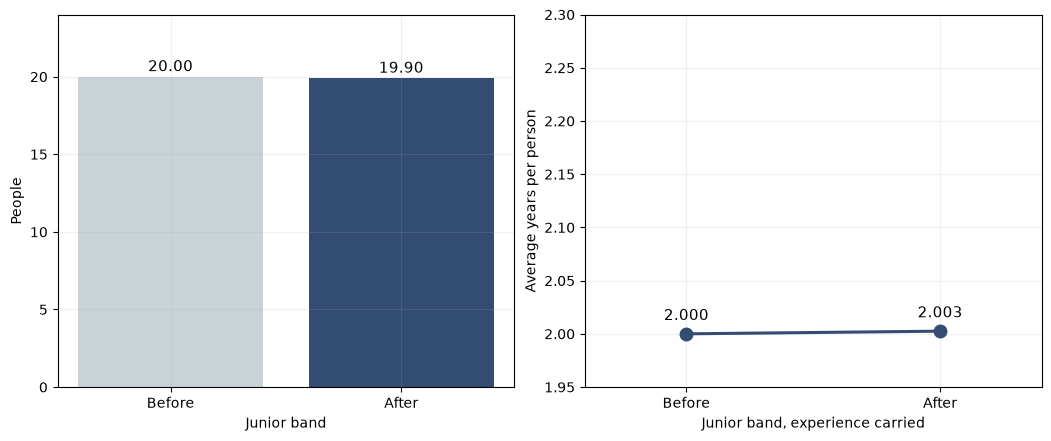

- **People in the band after:** 19.90
- **Total experience after (person-years):** 39.85
- **Average experience after (years):** 2.003
- **Change in the average (years):** 0.003
- **Aging alone would add (years):** 0.0025

Leavers = 0.01 x 0.5 x 20 = 0.10, so people = 20 - 0.10 = 19.90. Experience = 40.0 + 0.050 - 0.10 x 2.0 = 39.850. Average = 39.850/19.90 = 2.003, a change of 0.003 years against 0.0025 from aging. Leavers took their own share, so the average moved by about the aging alone.

In [6]:
show(experience_leaves(attrition=0.5, dt=0.01, model='carried'))

**Use the idea.** Plot the ratio of experience to people, not only the totals; the parallel-stock bug hides in the totals.

**Where the conclusion applies.** One band, no hires and no maturation, short steps. The parallel version is the bug the chapter describes, computed here by plain arithmetic and not by the chapter's code. Aging and departing experience use the start-of-step state, which is why the chapter's test uses a short step.

*Constructed example: the chapter's starting band of 20 people and 40 person-years, advanced with the chapter's advance function.*

Every setting the interactive reader offers for this demonstration:

In [7]:
sweep(experience_leaves, [('attrition', [0.2, 0.5]), ('dt', [0.01, 0.1]), ('model', ['carried', 'parallel'])])

- **attrition = 0.2, dt = 0.01, model = carried**: People in the band after 19.96; Total experience after (person-years) 39.97; Average experience after (years) 2.003; Change in the average (years) 0.003; Aging alone would add (years) 0.0025
- **attrition = 0.2, dt = 0.01, model = parallel**: People in the band after 19.96; Total experience after (person-years) 40.05; Average experience after (years) 2.007; Change in the average (years) 0.007; Aging alone would add (years) 0.0025
- **attrition = 0.2, dt = 0.1, model = carried**: People in the band after 19.60; Total experience after (person-years) 39.70; Average experience after (years) 2.026; Change in the average (years) 0.026; Aging alone would add (years) 0.0250
- **attrition = 0.2, dt = 0.1, model = parallel**: People in the band after 19.60; Total experience after (person-years) 40.50; Average experience after (years) 2.066; Change in the average (years) 0.066; Aging alone would add (years) 0.0250
- **attrition = 0.5, dt = 0.01, model = carried**: People in the band after 19.90; Total experience after (person-years) 39.85; Average experience after (years) 2.003; Change in the average (years) 0.003; Aging alone would add (years) 0.0025
- **attrition = 0.5, dt = 0.01, model = parallel**: People in the band after 19.90; Total experience after (person-years) 40.05; Average experience after (years) 2.013; Change in the average (years) 0.013; Aging alone would add (years) 0.0025
- **attrition = 0.5, dt = 0.1, model = carried**: People in the band after 19.00; Total experience after (person-years) 38.50; Average experience after (years) 2.026; Change in the average (years) 0.026; Aging alone would add (years) 0.0250
- **attrition = 0.5, dt = 0.1, model = parallel**: People in the band after 19.00; Total experience after (person-years) 40.50; Average experience after (years) 2.132; Change in the average (years) 0.132; Aging alone would add (years) 0.0250

## 2. What the surge does

*If headcount nearly doubles, how much does capacity rise?*

Hires add heads at once and capability slowly, because they arrive with none. With enough hires the junior band also gets greener, since newcomers arrive faster than the juniors mature; with few hires it does not.

    headcount(bands)
    effective_capacity(bands, 4.0)
    bands[0].average()

**Symbols and inputs.** Three bands start with 20, 30 and 50 people holding 40, 150 and 500 person-years. Hires enter the junior band with no experience. Effective capacity counts each person in proportion to their experience up to the ramp, and fully after it.

**Predict first.** With 40 hires per quarter and a four-year ramp, does capacity rise by more or less than headcount after 3 quarters?

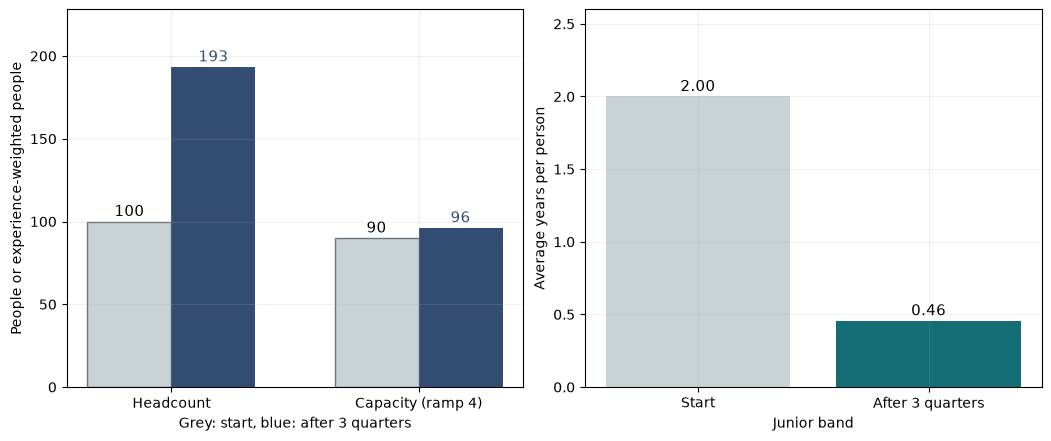

- **Headcount:** 100 to 193.4
- **Headcount rise (percent):** 93
- **Effective capacity:** 90.0 to 96.2
- **Capacity rise (percent):** 7
- **Junior average experience (years):** 2.00 to 0.46

40 hires x 3 quarters = 120 people entered; headcount rose by 193.4 - 100 = 93.4, so 120 - 93.4 = 26.6 left. Headcount rise = 93.4/100 = 0.934. Capacity on a 4-year ramp changed by 96.2 - 90.0 = 6.2, which is 6.2/90.0 = 0.069. The gap between the two rises is the dilution a headcount model reports as zero.

In [8]:
show(surge(hires=40.0, ramp=4.0))

**Use the idea.** Report capacity beside headcount whenever the workforce is changing fast.

**Where the conclusion applies.** Three bands, the chapter's maturation and attrition rates per quarter and no training cost. The model steps one quarter at a time and everyone present accrues 0.25 years of experience per quarter, so the ramp is in years.

*Constructed example: the chapter's three-band workforce and its 40 hires per quarter, with other hire sizes and a two-year ramp defined for this reader.*

Every setting the interactive reader offers for this demonstration:

In [9]:
sweep(surge, [('hires', [10.0, 20.0, 40.0, 60.0]), ('ramp', [2.0, 4.0])])

- **hires = 10.0, ramp = 2.0**: Headcount 100 to 111.8; Headcount rise (percent) 12; Effective capacity 100.0 to 97.1; Capacity rise (percent) -3; Junior average experience (years) 2.00 to 0.88
- **hires = 10.0, ramp = 4.0**: Headcount 100 to 111.8; Headcount rise (percent) 12; Effective capacity 90.0 to 89.5; Capacity rise (percent) -1; Junior average experience (years) 2.00 to 0.88
- **hires = 20.0, ramp = 2.0**: Headcount 100 to 139.0; Headcount rise (percent) 39; Effective capacity 100.0 to 106.4; Capacity rise (percent) 6; Junior average experience (years) 2.00 to 0.61
- **hires = 20.0, ramp = 4.0**: Headcount 100 to 139.0; Headcount rise (percent) 39; Effective capacity 90.0 to 91.7; Capacity rise (percent) 2; Junior average experience (years) 2.00 to 0.61
- **hires = 40.0, ramp = 2.0**: Headcount 100 to 193.4; Headcount rise (percent) 93; Effective capacity 100.0 to 125.1; Capacity rise (percent) 25; Junior average experience (years) 2.00 to 0.46
- **hires = 40.0, ramp = 4.0**: Headcount 100 to 193.4; Headcount rise (percent) 93; Effective capacity 90.0 to 96.2; Capacity rise (percent) 7; Junior average experience (years) 2.00 to 0.46
- **hires = 60.0, ramp = 2.0**: Headcount 100 to 247.8; Headcount rise (percent) 148; Effective capacity 100.0 to 138.7; Capacity rise (percent) 39; Junior average experience (years) 2.00 to 0.40
- **hires = 60.0, ramp = 4.0**: Headcount 100 to 247.8; Headcount rise (percent) 148; Effective capacity 90.0 to 100.7; Capacity rise (percent) 12; Junior average experience (years) 2.00 to 0.40

## 3. Read headcount and average experience together

*What does it tell you when headcount and average experience move in different directions?*

Each pairing of directions is a different story: growing and diluting, aging in place, or the experienced people leaving. Aging pushes the average up over time, so the dilution shows most clearly early in a surge.

    headcount(bands)
    bands[0].average()

**Symbols and inputs.** Headcount is people across all bands. Average experience is total person-years divided by headcount. The three scenarios differ only in hiring and attrition.

**Predict first.** Under the senior band leaving, do headcount and average experience both fall after one quarter?

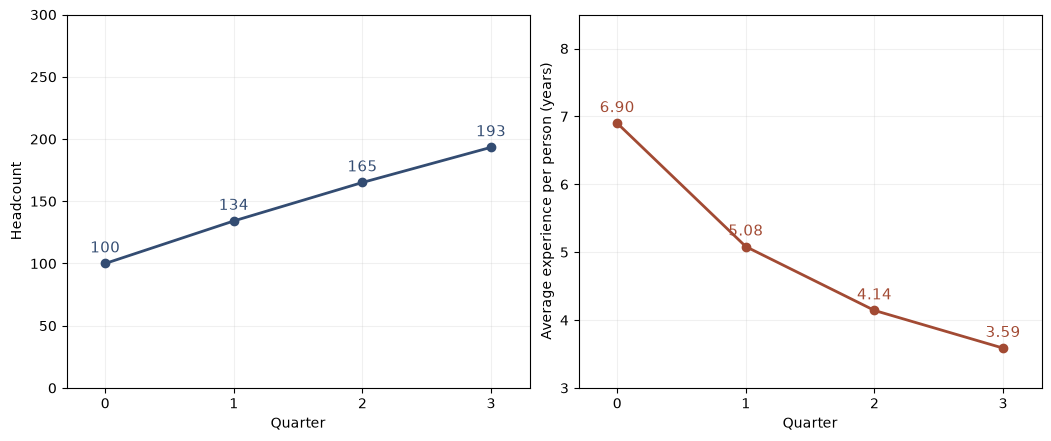

- **Scenario:** Hiring surge
- **Headcount:** 100 to 193.4 (rising)
- **Average experience (years):** 6.90 to 3.59 (falling)
- **Reading:** growing and diluting at once

Start: 690 person-years / 100 people = 6.90 years. After 3 quarter(s): 693.6 / 193.4 = 3.59 years, a change of (-3.31). Headcount changed by 93.4. Headcount rising with average experience falling reads as growing and diluting at once.

In [10]:
show(three_curves(scenario='surge', steps=3))

**Use the idea.** Plot both curves and read them as a pair, not one at a time.

**Where the conclusion applies.** Constructed scenarios in which the senior band loses 0.8 of its people per quarter in the third; real attrition is rarely uniform across bands, which a single rate cannot show.

*Constructed example: the chapter's three-band workforce under three scenarios defined for this reader, advanced with the chapter's advance function.*

Every setting the interactive reader offers for this demonstration:

In [11]:
sweep(three_curves, [('scenario', ['surge', 'aging', 'exodus']), ('steps', [1, 3])])

- **scenario = surge, steps = 1**: Scenario Hiring surge; Headcount 100 to 134.2 (rising); Average experience (years) 6.90 to 5.08 (falling); Reading growing and diluting at once
- **scenario = surge, steps = 3**: Scenario Hiring surge; Headcount 100 to 193.4 (rising); Average experience (years) 6.90 to 3.59 (falling); Reading growing and diluting at once
- **scenario = aging, steps = 1**: Scenario Aging in place; Headcount 100 to 100.0 (flat); Average experience (years) 6.90 to 7.15 (rising); Reading a workforce aging in place
- **scenario = aging, steps = 3**: Scenario Aging in place; Headcount 100 to 100.0 (flat); Average experience (years) 6.90 to 7.65 (rising); Reading a workforce aging in place
- **scenario = exodus, steps = 1**: Scenario Senior band leaving; Headcount 100 to 60.0 (falling); Average experience (years) 6.90 to 5.25 (falling); Reading leavers are the experienced ones, so capability falls faster than heads
- **scenario = exodus, steps = 3**: Scenario Senior band leaving; Headcount 100 to 40.0 (falling); Average experience (years) 6.90 to 4.50 (falling); Reading leavers are the experienced ones, so capability falls faster than heads

## 4. The recommendation that reverses

*Inside a short horizon, how much capability does each person hired actually deliver?*

Hires arrive with no experience, so within a short horizon with a long ramp they add heads and little capability. The ratio climbs toward one as the hires mature.

    headcount(bands)
    effective_capacity(bands, 4.0)

**Symbols and inputs.** Heads added is headcount with the surge minus headcount without it after the same number of quarters. Capacity per head is the capacity gained divided by heads added. A headcount model assumes 1.00.

**Predict first.** After 1 quarter on a four-year ramp, how much capacity does a head added by hiring deliver?

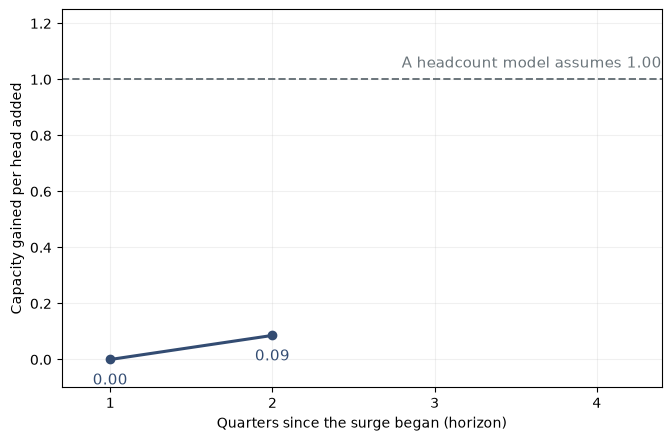

- **Heads added by hiring:** 76.0
- **Capacity gained:** 6.53
- **Capacity per head added:** 0.09
- **Shortfall against 1.00 per head:** 0.91

With 40 hires per quarter against none, 76.0 more people remain after 2 quarter(s). On a 4-year ramp they add 6.53 of capacity. Capacity per head = 6.53/76.0 = 0.09, so the shortfall against a headcount model is 1.00 - 0.09 = 0.91. Each added head delivers a fraction of a head inside this horizon, and the training cost, which this model omits, would lower it further.

In [12]:
show(per_head(horizon=2, ramp=4.0))

**Use the idea.** State the horizon next to a hiring recommendation; the case for hiring has to be made on the capability curve.

**Where the conclusion applies.** No training cost, which the chapter says its model omits and which would lower the ratio. Beyond the horizon where hires mature the headcount and chain models agree.

*Constructed example: the chapter's surge of 40 hires per quarter against a no-hiring run, compared with the chapter's effective_capacity.*

Every setting the interactive reader offers for this demonstration:

In [13]:
sweep(per_head, [('horizon', [1, 2, 3, 4]), ('ramp', [2.0, 4.0])])

- **horizon = 1, ramp = 2.0**: Heads added by hiring 40.0; Capacity gained 2.50; Capacity per head added 0.06; Shortfall against 1.00 per head 0.94
- **horizon = 1, ramp = 4.0**: Heads added by hiring 40.0; Capacity gained 0.00; Capacity per head added 0.00; Shortfall against 1.00 per head 1.00
- **horizon = 2, ramp = 2.0**: Heads added by hiring 76.0; Capacity gained 18.25; Capacity per head added 0.24; Shortfall against 1.00 per head 0.76
- **horizon = 2, ramp = 4.0**: Heads added by hiring 76.0; Capacity gained 6.53; Capacity per head added 0.09; Shortfall against 1.00 per head 0.91
- **horizon = 3, ramp = 2.0**: Heads added by hiring 108.8; Capacity gained 40.57; Capacity per head added 0.37; Shortfall against 1.00 per head 0.63
- **horizon = 3, ramp = 4.0**: Heads added by hiring 108.8; Capacity gained 12.79; Capacity per head added 0.12; Shortfall against 1.00 per head 0.88
- **horizon = 4, ramp = 2.0**: Heads added by hiring 139.0; Capacity gained 58.20; Capacity per head added 0.42; Shortfall against 1.00 per head 0.58
- **horizon = 4, ramp = 4.0**: Heads added by hiring 139.0; Capacity gained 23.21; Capacity per head added 0.17; Shortfall against 1.00 per head 0.83

## Exercises

Try each before opening the answer. The settings above let you check the numbers.

### Exercise 1

With dt = 0.1 and attrition 0.2, how many people leave the junior band in one step?

<details><summary>Answer</summary>

0.1 x 0.2 x 20 = 0.4 people, leaving 19.6.

</details>

### Exercise 2

If 120 people entered over three quarters and headcount rose by 93.4, how many left?

<details><summary>Answer</summary>

120 - 93.4 = 26.6 people left through attrition.

</details>

### Exercise 3

Start with 690 person-years among 100 people. What is the average experience?

<details><summary>Answer</summary>

690 / 100 = 6.9 years per person.

</details>

---

From *Systems Thinking with AI* by Jason Karpeles. Copyright Jason Karpeles. All rights reserved.

Interactive companion: https://karpeles.com/companions/systems-thinking-with-ai/